# STRING Ground Truth Collection
Build protein-protein association ground truth from STRING database for the protein embedding benchmark.

STRING integrates multiple evidence channels (experimental, co-expression, text mining, databases, genomic context) into a combined confidence score per protein pair.

**Cutoff:** combined_score ≥ 700 (i.e. 0.7, high confidence)

**Required files** (download from https://string-db.org/cgi/download?species_text=Homo+sapiens):
- `9606.protein.links.v12.0.txt.gz` — combined scores for all protein pairs
- `9606.protein.aliases.v12.0.txt.gz` — ID mapping (Ensembl → UniProt etc.)

In [1]:
from _common import CACHE, FASTA, fetch, require_manual  # noqa: F401
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gzip
from collections import defaultdict
from datetime import datetime
from matplotlib.patches import Patch

# 1. Load STRING protein links

The links file has 3 columns: `protein1`, `protein2`, `combined_score`  
Protein IDs are Ensembl format: `9606.ENSP00000000233`  
Scores are integers (multiplied by 1000), so 700 = 0.7 confidence

In [3]:
# Adjust this path to where you downloaded the file
links_path = fetch(
    'https://stringdb-downloads.org/download/protein.links.v12.0/9606.protein.links.v12.0.txt.gz',
    '9606.protein.links.v12.0.txt.gz',
)

print("Loading STRING links (this may take a minute)...")
df_links = pd.read_csv(links_path, sep=' ', compression='gzip')
print(f"Total interactions: {len(df_links):,}")
print(f"Columns: {list(df_links.columns)}")
df_links.head()

Loading STRING links (this may take a minute)...
Total interactions: 13,715,404
Columns: ['protein1', 'protein2', 'combined_score']


,protein1,protein2,combined_score
0,9606.ENSP00000000233,9606.ENSP00000356607,173
1,9606.ENSP00000000233,9606.ENSP00000427567,154
2,9606.ENSP00000000233,9606.ENSP00000253413,151
3,9606.ENSP00000000233,9606.ENSP00000493357,471
4,9606.ENSP00000000233,9606.ENSP00000324127,201


In [4]:
# Score distribution
print(f"Score statistics:")
print(f"  Min: {df_links['combined_score'].min()}")
print(f"  Median: {df_links['combined_score'].median()}")
print(f"  Mean: {df_links['combined_score'].mean():.0f}")
print(f"  Max: {df_links['combined_score'].max()}")

# How many interactions at different cutoffs
print(f"\nInteractions at different cutoffs:")
for cutoff in [150, 400, 700, 900]:
    n = (df_links['combined_score'] >= cutoff).sum()
    print(f"  ≥ {cutoff} ({cutoff/1000:.1f}): {n:>10,} interactions")

Score statistics:
  Min: 150
  Median: 209.0
  Mean: 269
  Max: 999

Interactions at different cutoffs:
  ≥ 150 (0.1): 13,715,404 interactions
  ≥ 400 (0.4):  1,858,944 interactions
  ≥ 700 (0.7):    473,860 interactions
  ≥ 900 (0.9):    201,712 interactions


In [5]:
# Apply cutoff: combined_score >= 700 (high confidence)
SCORE_CUTOFF = 700

df_hc = df_links[df_links['combined_score'] >= SCORE_CUTOFF].copy()
print(f"High confidence interactions (≥ {SCORE_CUTOFF}): {len(df_hc):,}")

# Unique proteins in high-confidence network
string_proteins = set(df_hc['protein1'].unique()) | set(df_hc['protein2'].unique())
print(f"Unique STRING proteins: {len(string_proteins):,}")
print(f"\nSample IDs: {list(string_proteins)[:5]}")

High confidence interactions (≥ 700): 473,860
Unique STRING proteins: 16,201

Sample IDs: ['9606.ENSP00000219204', '9606.ENSP00000327453', '9606.ENSP00000357106', '9606.ENSP00000367476', '9606.ENSP00000366509']


# 2. Map STRING IDs (Ensembl) → UniProt accessions

STRING uses Ensembl protein IDs (`9606.ENSP00000...`).  
The aliases file maps these to various identifiers including UniProt.

In [6]:
# Adjust this path
aliases_path = fetch(
    'https://stringdb-downloads.org/download/protein.aliases.v12.0/9606.protein.aliases.v12.0.txt.gz',
    '9606.protein.aliases.v12.0.txt.gz',
)

print("Loading STRING aliases...")
df_aliases = pd.read_csv(aliases_path, sep='\t', compression='gzip')
print(f"Total alias entries: {len(df_aliases):,}")
print(f"Columns: {list(df_aliases.columns)}")
df_aliases.head(10)

Loading STRING aliases...
Total alias entries: 628,096,921
Columns: ['#string_protein_id', 'alias', 'source']


,#string_protein_id,alias,source
0,23.BEL05_00025,23,RefSeq_xref_taxon
1,23.BEL05_00025,A0A1E5IUA8,UniProt_AC
2,23.BEL05_00025,A0A1E5IUA8_SHECO,UniProt_ID
3,23.BEL05_00025,BEL05_00025,RefSeq
4,23.BEL05_00025,BEL05_00025,RefSeq_locus
5,23.BEL05_00025,BEL05_00025,UniProt_GN_ORFNames
6,23.BEL05_00025,FAD-dependent oxidoreductase,UniProt_DE_SubName_Full
7,23.BEL05_00025,Hypothetical protein,RefSeq_product
8,23.BEL05_00025,NZ_MCBT01000037.1,UniProt_DR_RefSeq
9,23.BEL05_00025,WP_069671263.1,UniProt_DR_RefSeq


In [7]:
# Check what alias sources are available
print("Alias sources:")
print(df_aliases['source'].value_counts().head(20))

Alias sources:
source
RefSeq                     65559809
RefSeq_product             62934233
UniProt_AC                 46575449
UniProt_ID                 46107338
UniProt_DR_RefSeq          41317474
UniProt_GN_ORFNames        40368268
RefSeq_locus               37785258
UniProt_DE_SubName_Full    30817524
RefSeq_short               27467981
KEGG_PRODUCT               17747289
Uniprot                    16595137
KEGG_KEGGID_SHORT          14173004
KEGG_KEGGID                14173004
KEGG_NCBI                  14172992
UniProt_DE_RecName_Full    12176655
Ensembl_RefSeq              8827793
Ensembl_RefSeq_short        8819381
Ensembl_transcript          8228190
UniProt_GN_Name             8157491
Ensembl_translation         8054193
Name: count, dtype: int64


In [8]:
uniprot_aliases = df_aliases[df_aliases['source'] == 'UniProt_AC'].copy()
print(f"UniProt alias entries: {len(uniprot_aliases):,}")

id_col = uniprot_aliases.columns[0]
alias_col = uniprot_aliases.columns[1]

# Vectorized groupby instead of iterrows
string_to_uniprot = (
    uniprot_aliases
    .groupby(id_col)[alias_col]
    .apply(set)
    .to_dict()
)

print(f"STRING proteins with UniProt mapping: {len(string_to_uniprot):,}")

for i, (k, v) in enumerate(string_to_uniprot.items()):
    if i >= 5: break
    print(f"  {k} → {v}")

UniProt alias entries: 46,575,449
STRING proteins with UniProt mapping: 46,107,338
  100053.GCA_002009845_00001 → {'V6IGA7'}
  100053.GCA_002009845_00003 → {'V6IA65'}
  100053.GCA_002009845_00004 → {'V6I408'}
  100053.GCA_002009845_00005 → {'V6I4L6'}
  100053.GCA_002009845_00006 → {'V6IGD2'}


# 3. Convert interactions to UniProt pairs

In [9]:
# Convert STRING interactions to UniProt pairs
# For proteins mapping to multiple UniProt IDs, we expand all combinations
# Map STRING IDs to UniProt in bulk
df_hc = df_hc.copy()
df_hc['up1'] = df_hc['protein1'].map(string_to_uniprot)
df_hc['up2'] = df_hc['protein2'].map(string_to_uniprot)

# Drop rows where either protein has no UniProt mapping
mapped = df_hc.dropna(subset=['up1', 'up2'])
unmapped = len(df_hc) - len(mapped)
print(f"Unmapped interactions: {unmapped:,}")

# Explode the sets into individual pairs
positive_pairs = set()
for _, row in mapped.iterrows():
    for up1 in row['up1']:
        for up2 in row['up2']:
            if up1 != up2:
                pair = tuple(sorted([up1, up2]))
                positive_pairs.add(pair)

print(f"Unmapped interactions (at least one protein missing UniProt): {unmapped:,}")
print(f"Unique positive UniProt pairs: {len(positive_pairs):,}")

# Unique UniProt proteins in positive set
string_uniprot_proteins = set()
for p1, p2 in positive_pairs:
    string_uniprot_proteins.add(p1)
    string_uniprot_proteins.add(p2)
print(f"Unique UniProt proteins in STRING network: {len(string_uniprot_proteins):,}")

Unmapped interactions: 15,962
Unmapped interactions (at least one protein missing UniProt): 15,962
Unique positive UniProt pairs: 6,972,774
Unique UniProt proteins in STRING network: 77,162


# 4. Build the ground truth matrix

Unlike KEGG/Reactome/CORUM/GO CC where we derived pairs from group co-membership, STRING already gives us direct pairwise scores.

- `1` = positive (combined_score ≥ 700, i.e. high-confidence association)
- `0` = negative (both proteins in STRING but no high-confidence edge)
- `NaN` = at least one protein not in the STRING network

Proteins ordered alphabetically — same order as all other matrices.

In [10]:
from Bio import SeqIO

fasta_path = FASTA

protein_sequences = {}
for record in SeqIO.parse(fasta_path, 'fasta'):
    protein_id = record.id.split('|')[1]
    protein_sequences[protein_id] = str(record.seq)

all_proteins = list(protein_sequences.keys())
all_proteins_sorted = sorted(all_proteins)
n = len(all_proteins_sorted)
prot_to_idx = {p: i for i, p in enumerate(all_proteins_sorted)}

print(f"Total proteins: {n}")
print(f"Matrix shape: {n} x {n}")

Total proteins: 20372
Matrix shape: 20372 x 20372


In [11]:
# Check overlap
fasta_set = set(all_proteins)
in_both = string_uniprot_proteins & fasta_set
string_only = string_uniprot_proteins - fasta_set

print(f"STRING UniProt proteins: {len(string_uniprot_proteins):,}")
print(f"In both STRING and FASTA: {len(in_both):,}")
print(f"In STRING only (not in FASTA): {len(string_only):,}")

if string_only:
    print(f"\nSample STRING-only IDs: {sorted(string_only)[:10]}")

STRING UniProt proteins: 77,162
In both STRING and FASTA: 15,758
In STRING only (not in FASTA): 61,404

Sample STRING-only IDs: ['A0A024QZ45', 'A0A024QZG0', 'A0A024R072', 'A0A024R077', 'A0A024R0D3', 'A0A024R0E9', 'A0A024R0H3', 'A0A024R0P9', 'A0A024R0V2', 'A0A024R284']


In [12]:
# For STRING, 'in the network' means the protein has at least one
# high-confidence edge. We also need to consider all STRING proteins
# (even those whose edges are all below cutoff) as 'in STRING'.
# Let's use all proteins that appear in the aliases file with a UniProt mapping.

all_string_uniprot = set()
for uniprots in string_to_uniprot.values():
    all_string_uniprot.update(uniprots)

# Filter to those in our FASTA
string_in_fasta = sorted([p for p in all_string_uniprot if p in prot_to_idx])
string_indices = np.array([prot_to_idx[p] for p in string_in_fasta])

print(f"All STRING proteins (any score): {len(all_string_uniprot):,}")
print(f"STRING proteins in our FASTA: {len(string_in_fasta):,}")

All STRING proteins (any score): 46,566,788
STRING proteins in our FASTA: 18,950


In [13]:
# Initialize all NaN
string_matrix = np.full((n, n), np.nan, dtype=np.float32)

# Set all STRING×STRING pairs to 0 (negative by default)
string_matrix[np.ix_(string_indices, string_indices)] = 0.0
print(f"Set {len(string_indices)}x{len(string_indices)} STRING submatrix to 0")

Set 18950x18950 STRING submatrix to 0


In [14]:
# Set positives from our high-confidence pairs
n_set = 0
n_skipped = 0

for p1, p2 in positive_pairs:
    if p1 in prot_to_idx and p2 in prot_to_idx:
        i, j = prot_to_idx[p1], prot_to_idx[p2]
        string_matrix[i, j] = 1.0
        string_matrix[j, i] = 1.0
        n_set += 1
    else:
        n_skipped += 1

print(f"Set {n_set:,} positive pairs (both directions)")
print(f"Skipped {n_skipped:,} pairs (protein not in FASTA)")

Set 224,991 positive pairs (both directions)
Skipped 6,747,783 pairs (protein not in FASTA)


In [15]:
# Set diagonal to NaN
np.fill_diagonal(string_matrix, np.nan)

# Verify counts
upper = string_matrix[np.triu_indices(n, k=1)]
n_pos = np.nansum(upper == 1)
n_neg = np.nansum(upper == 0)
n_nan = np.sum(np.isnan(upper))

print(f"Upper triangle counts:")
print(f"  Positive (1): {int(n_pos):>12,}")
print(f"  Negative (0): {int(n_neg):>12,}")
print(f"  NaN:          {int(n_nan):>12,}")
print(f"  Total:        {len(upper):>12,}")
print(f"\n  Pos/Neg ratio: {n_pos/n_neg:.6f}")
print(f"  Matrix is symmetric: {np.allclose(string_matrix, string_matrix.T, equal_nan=True)}")

Upper triangle counts:
  Positive (1):      224,991
  Negative (0):  179,316,784
  NaN:            27,957,231
  Total:         207,499,006

  Pos/Neg ratio: 0.001255
  Matrix is symmetric: True


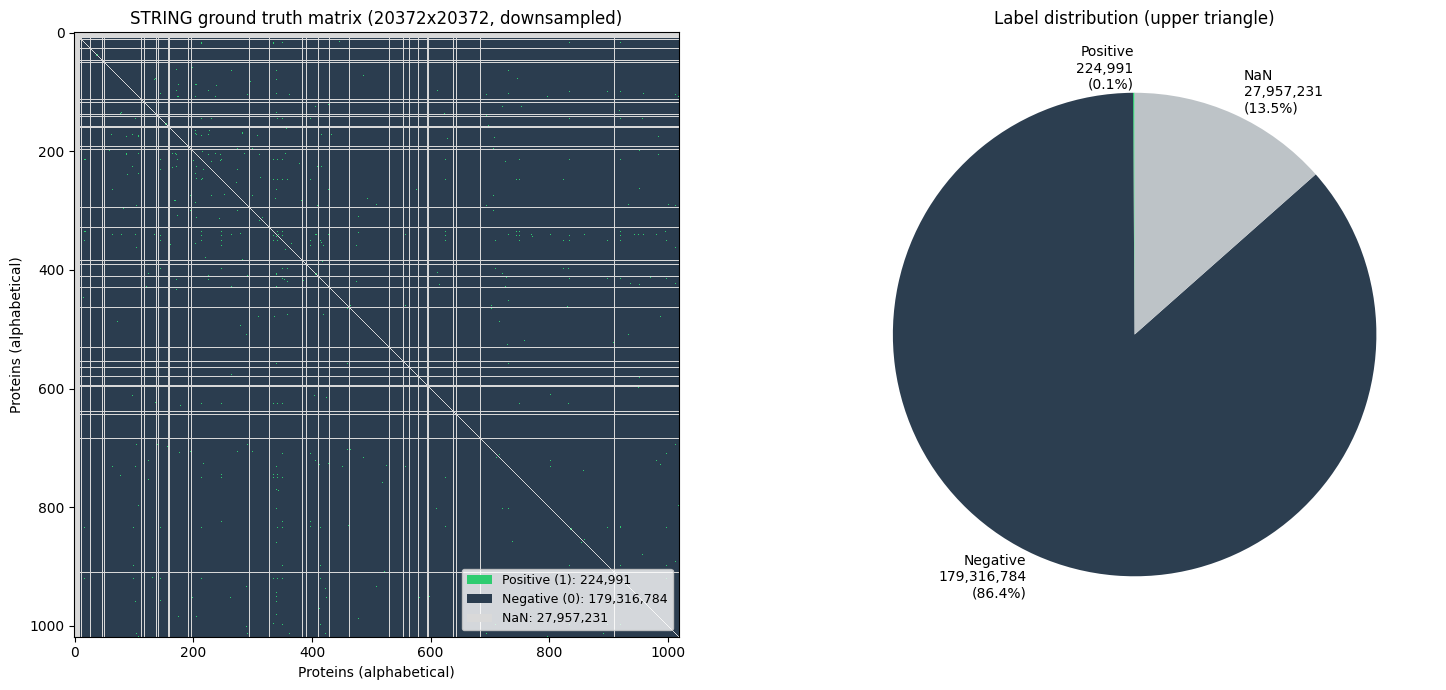

In [16]:
# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

step = max(1, n // 1000)
display_matrix = string_matrix[::step, ::step]

rgb = np.zeros((*display_matrix.shape, 3), dtype=np.float32)
nan_mask = np.isnan(display_matrix)
neg_mask = display_matrix == 0
pos_mask = display_matrix == 1

rgb[nan_mask] = [0.85, 0.85, 0.85]
rgb[neg_mask] = [0.17, 0.24, 0.31]
rgb[pos_mask] = [0.18, 0.80, 0.44]

axes[0].imshow(rgb, aspect='equal', interpolation='nearest')
axes[0].set_title(f"STRING ground truth matrix ({n}x{n}, downsampled)", fontsize=12)
axes[0].set_xlabel("Proteins (alphabetical)")
axes[0].set_ylabel("Proteins (alphabetical)")

legend_elements = [
    Patch(facecolor=[0.18, 0.80, 0.44], label=f'Positive (1): {int(n_pos):,}'),
    Patch(facecolor=[0.17, 0.24, 0.31], label=f'Negative (0): {int(n_neg):,}'),
    Patch(facecolor=[0.85, 0.85, 0.85], label=f'NaN: {int(n_nan):,}'),
]
axes[0].legend(handles=legend_elements, loc='lower right', fontsize=9)

sizes_plot = [int(n_pos), int(n_neg), int(n_nan)]
labels = [f'Positive\n{int(n_pos):,}\n({n_pos/len(upper)*100:.1f}%)',
          f'Negative\n{int(n_neg):,}\n({n_neg/len(upper)*100:.1f}%)',
          f'NaN\n{int(n_nan):,}\n({n_nan/len(upper)*100:.1f}%)']
colors = ['#2ecc71', '#2c3e50', '#bdc3c7']

axes[1].pie(sizes_plot, labels=labels, colors=colors, startangle=90, textprops={'fontsize': 10})
axes[1].set_title('Label distribution (upper triangle)', fontsize=12)

plt.tight_layout()
plt.show()

In [17]:
from pathlib import Path
from omicsfm.attention import GT_DIR_DEFAULT, save_ppi_ground_truth

# save_ppi_ground_truth stores only the positives and the covered-protein
# universe (~36x smaller, reconstructs the dense matrix exactly) and will
# not replace an existing file: published results are pinned to the
# matrices in reference/, and these source databases change over time.
# save

import os

save_ppi_ground_truth(
    path=Path(GT_DIR_DEFAULT) / "string_ground_truth_matrix.npz",
    matrix=string_matrix,
    overwrite=False,   # True re-pins the published matrix; every result
                       # and figure derived from it must be regenerated too
)

with open("string_ground_truth_proteins.tsv", "w") as f:
    f.write("idx\tprotein\n")
    for i, p in enumerate(all_proteins_sorted):
        f.write(f"{i}\t{p}\n")

npz_size = os.path.getsize("string_ground_truth_matrix.npz") / 1e6
print(f"Saved string_ground_truth_matrix.npz ({npz_size:.1f} MB)")
print(f"Saved string_ground_truth_proteins.tsv")
print(f"\nParameters used:")
print(f"  STRING version: 12.0")
print(f"  Score cutoff: {SCORE_CUTOFF} (combined_score)")
print(f"  Network type: full (functional + physical)")
print(f"\nTo load later:")
print(f"  matrix = np.load('string_ground_truth_matrix.npz')['matrix']")
print(f"  # shape ({n}, {n}), values: 0, 1, NaN")

Saved string_ground_truth_matrix.npz (34.4 MB)
Saved string_ground_truth_proteins.tsv

Parameters used:
  STRING version: 12.0
  Score cutoff: 700 (combined_score)
  Network type: full (functional + physical)

To load later:
  matrix = np.load('string_ground_truth_matrix.npz')['matrix']
  # shape (20372, 20372), values: 0, 1, NaN
